In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(r"C:\Users\pc\Documents\Coffee Shop Sales.xlsx")

In [5]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[us] 
 2   transaction_time  149116 non-null  timedelta64[us]
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  str            
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  str            
 9   product_type      149116 non-null  str            
 10  product_detail    149116 non-null  str            
 11  sales             149116 non-null  float64        
 12  datetime          149116 non-null  datetime64[us] 
dtypes: datetime64[us](2), float64(2), int64(4), str(4), tim

In [7]:
df['transaction_time'] = df['transaction_time'].astype(str)
df['transaction_time'] = pd.to_timedelta(df['transaction_time'])

In [8]:
df['sales'] =df['transaction_qty'] * df['unit_price']
df['datetime'] = df['transaction_date'] + df['transaction_time']

In [10]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,sales,datetime
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023-01-01 07:06:11
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:08:56
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023-01-01 07:14:04
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01-01 07:20:24
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:22:41


In [11]:
df.describe()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,product_id,unit_price,sales,datetime
count,149116.000000,149116,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116
mean,74737.371872,2023-04-15 11:50:32.173609,0 days 12:14:15.815794,1.438276,5.342063,47.918607,3.382219,4.686367,2023-04-16 00:04:47.989404
min,1.000000,2023-01-01 00:00:00,0 days 06:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,2023-01-01 07:06:11
25%,37335.750000,2023-03-06 00:00:00,0 days 09:05:10.500000,1.000000,3.000000,33.000000,2.500000,3.000000,2023-03-06 13:37:08
50%,74727.500000,2023-04-24 00:00:00,0 days 11:15:28,1.000000,5.000000,47.000000,3.000000,3.750000,2023-04-24 08:24:32.500000
75%,112094.250000,2023-05-30 00:00:00,0 days 15:25:57,2.000000,8.000000,60.000000,3.750000,6.000000,2023-05-30 07:16:13
max,149456.000000,2023-06-30 00:00:00,0 days 20:59:32,8.000000,8.000000,87.000000,45.000000,360.000000,2023-06-30 20:57:19
std,43153.600016,NaN,0 days 03:45:57.901686,0.542509,2.074241,17.930020,2.658723,4.227099,NaN


In [12]:
df_location =df.groupby('store_location').agg({
     'sales': 'sum',
    'transaction_id': 'count'
 })
df_location

,sales,transaction_id
store_location,,
Astoria,232243.91,50599
Hell's Kitchen,236511.17,50735
Lower Manhattan,230057.25,47782


In [13]:
daily_sales_by_location = df.groupby(['transaction_date', 'store_location'])['sales'].sum().unstack()
daily_sales_by_location

store_location,Astoria,Hell's Kitchen,Lower Manhattan
transaction_date,,,
2023-01-01,868.40,851.45,788.35
2023-01-02,925.50,828.80,649.05
2023-01-03,902.75,906.25,756.00
2023-01-04,808.25,781.65,630.20
2023-01-05,903.05,714.90,800.90
...,...,...,...
2023-06-26,1975.10,1746.10,2154.70
2023-06-27,1861.55,1676.70,2437.40
2023-06-28,1758.10,1445.85,1524.95


In [14]:
#without using unstack()
test =df.groupby(['transaction_date', 'store_location'])['sales'].sum()
test

transaction_date  store_location 
2023-01-01        Astoria             868.40
                  Hell's Kitchen      851.45
                  Lower Manhattan     788.35
2023-01-02        Astoria             925.50
                  Hell's Kitchen      828.80
                                      ...   
2023-06-29        Hell's Kitchen     1298.55
                  Lower Manhattan    1299.45
2023-06-30        Astoria            1807.65
                  Hell's Kitchen     1904.93
                  Lower Manhattan    1768.74
Name: sales, Length: 543, dtype: float64

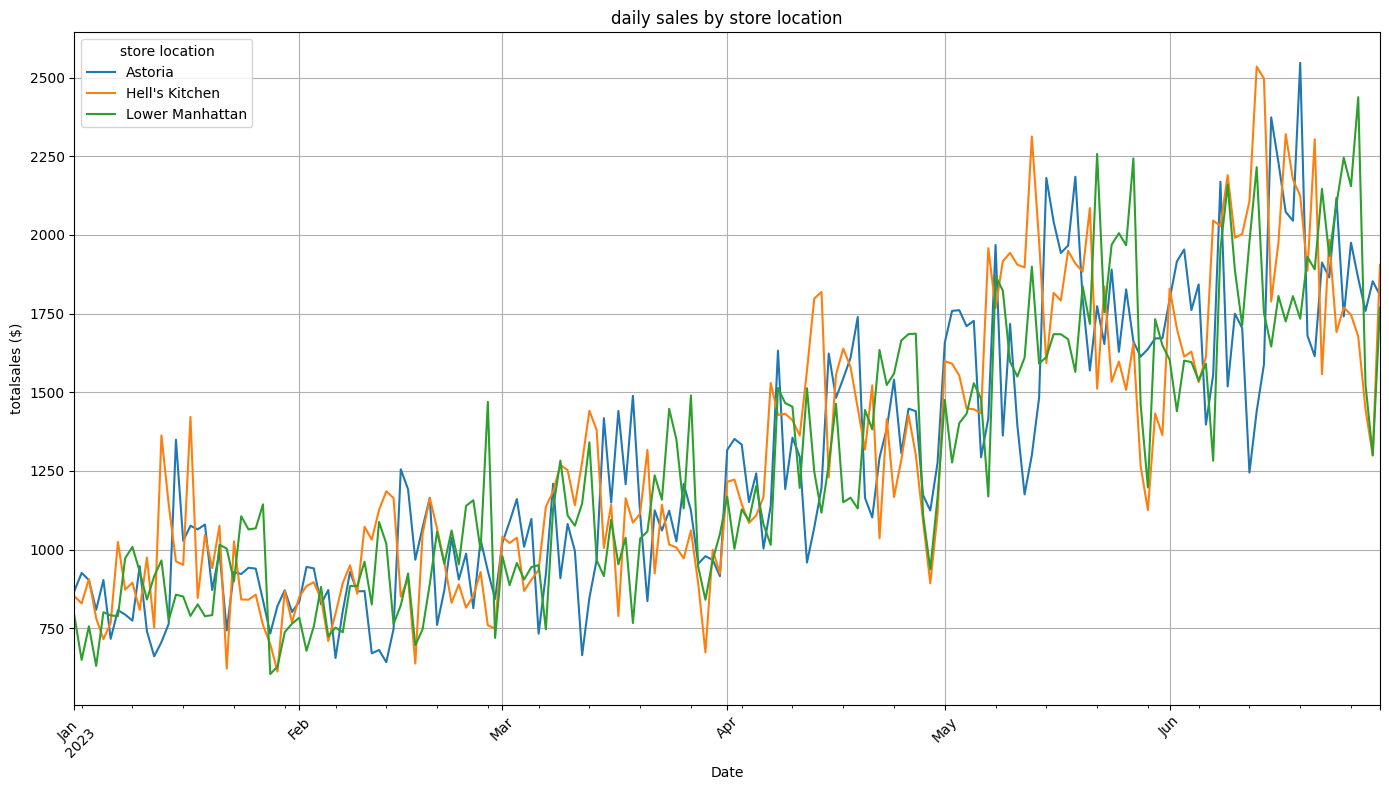

In [43]:
#plotting a line graph
daily_sales_by_location.plot(figsize=(14, 8), title='daily sales by store location')

plt.xlabel('Date')
plt.ylabel('totalsales ($)')

plt.legend(title='store location')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

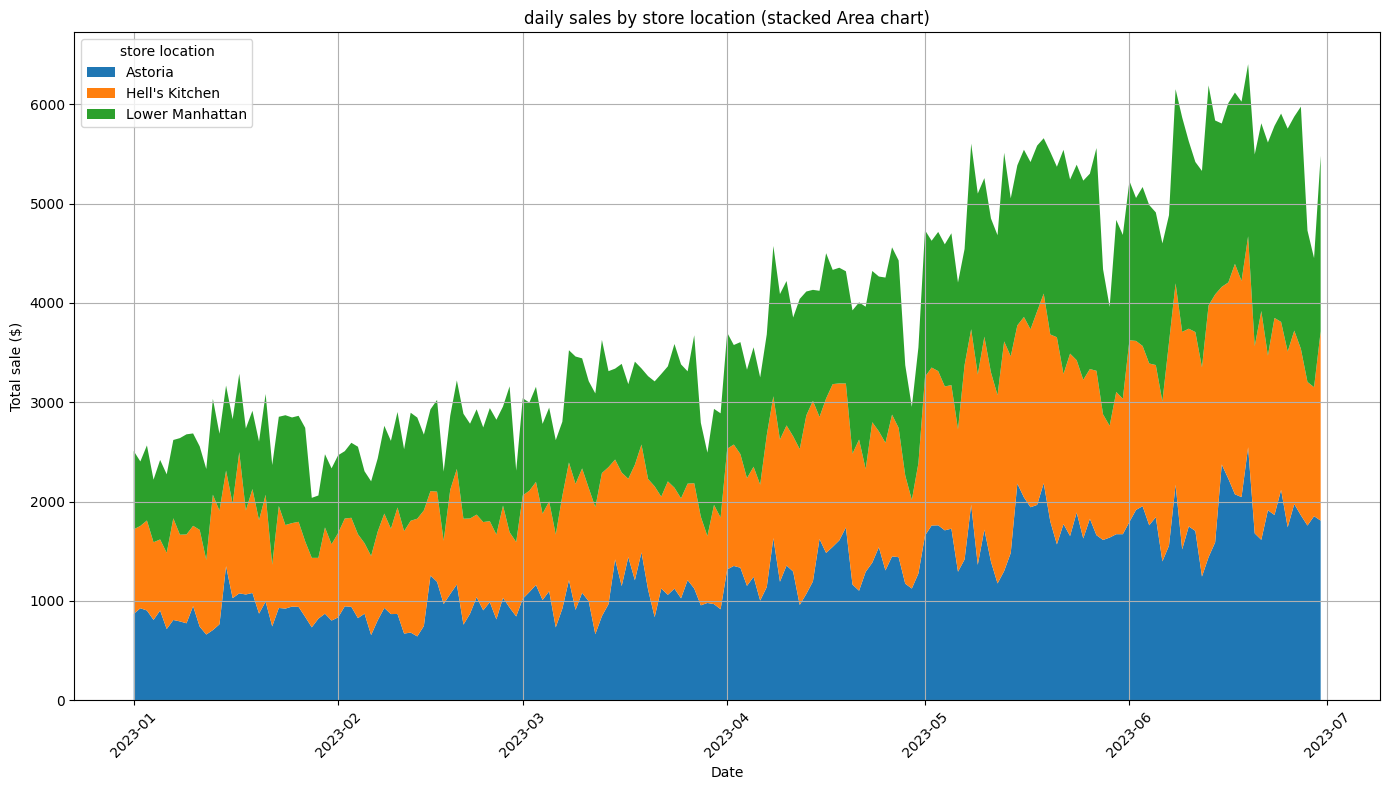

In [51]:
#plotting and are chart
plt.figure(figsize=(14, 8))
plt.stackplot(daily_sales_by_location.index, daily_sales_by_location.T, labels=daily_sales_by_location.columns)

plt.title('daily sales by store location (stacked Area chart)')
plt.xlabel('Date')
plt.ylabel('Total sale ($)')
plt.legend(title='store location', loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [65]:
daily_sales = df.groupby('transaction_date')['sale'].sum().reset_index()
df['day_of_week'] = df['datetime'].dt.day_name()

weekly_sales = df.groupby('day_of_week')['sales'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index() 

df['month'] = df['datetime'].dt.to_period('M')
monthly_sales = df.groupby('month')['sales'].sum().reset_index()

daily_sales, weekly_sales, monthly_sales


(    transaction_date     sale
 0         2023-01-01  2508.20
 1         2023-01-02  2403.35
 2         2023-01-03  2565.00
 3         2023-01-04  2220.10
 4         2023-01-05  2418.85
 ..               ...      ...
 176       2023-06-26  5875.90
 177       2023-06-27  5975.65
 178       2023-06-28  4728.90
 179       2023-06-29  4450.75
 180       2023-06-30  5481.32
 
 [181 rows x 2 columns],
   day_of_week      sales
 0      Monday  101677.28
 1     Tuesday   99455.94
 2   Wednesday  100313.54
 3    Thursday  100767.78
 4      Friday  101373.00
 5    Saturday   96894.48
 6      Sunday   98330.31,
      month      sales
 0  2023-01   81677.74
 1  2023-02   76145.19
 2  2023-03   98834.68
 3  2023-04  118941.08
 4  2023-05  156727.76
 5  2023-06  166485.88)

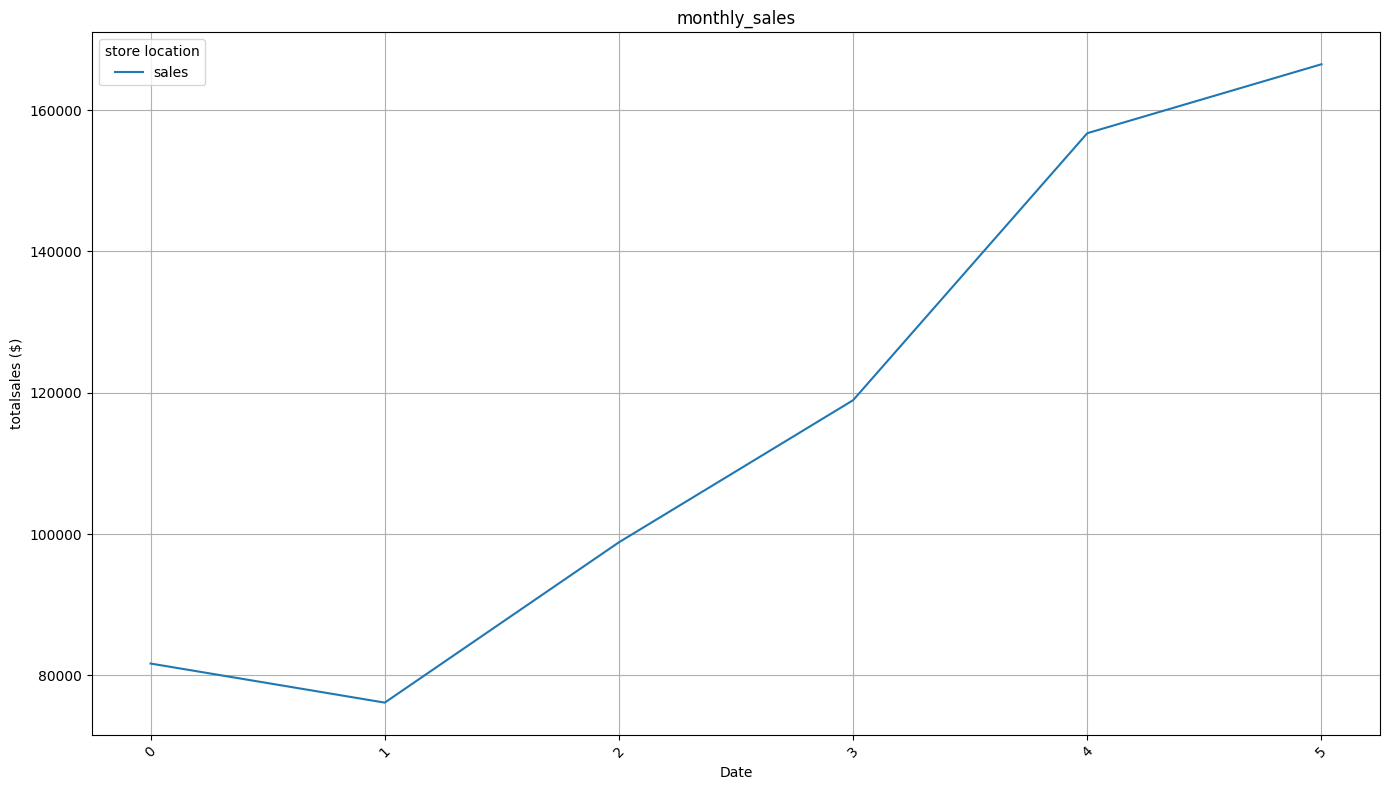

In [69]:
monthly_sales.plot(figsize=(14, 8), title='monthly_sales')

plt.xlabel('Date')
plt.ylabel('totalsales ($)')
plt.legend(title='store location')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [72]:
weekly_sales = df.groupby(['day_of_week', 'store_location'])['sales'].sum().unstack()

days_order =['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales =weekly_sales.reindex(days_order)
weekly_sales

store_location,Astoria,Hell's Kitchen,Lower Manhattan
day_of_week,,,
Monday,33928.29,33389.51,34359.48
Tuesday,31816.76,34846.47,32792.71
Wednesday,34244.63,33779.09,32289.82
Thursday,34140.37,33468.06,33159.35
Friday,33472.75,34743.18,33157.07
Saturday,31845.93,32599.23,32449.32
Sunday,32795.18,33685.63,31849.50


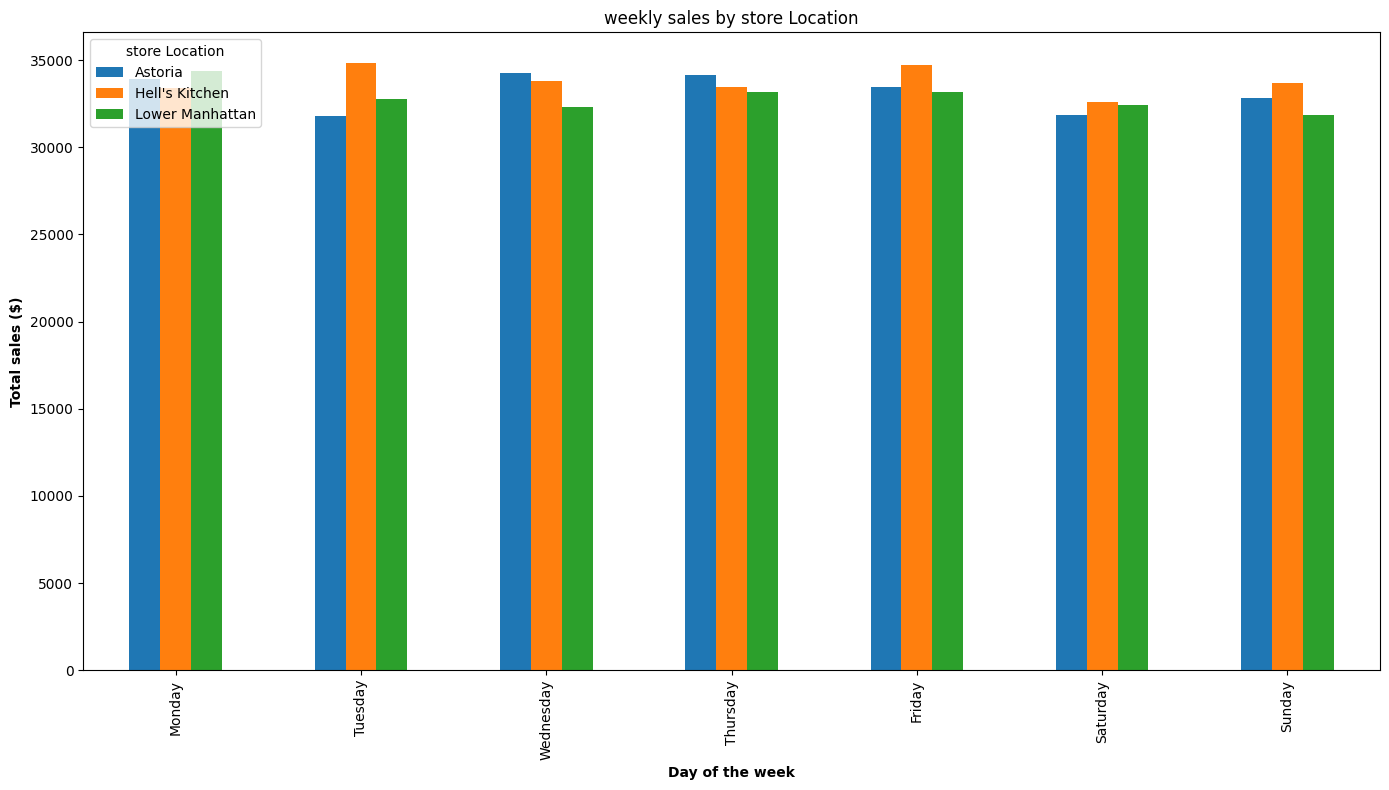

In [76]:
weekly_sales[["Astoria","Hell's Kitchen","Lower Manhattan"]].plot(kind='bar',figsize=(14, 8))

plt.xlabel('Day of the week', fontweight = 'bold')
plt.ylabel('Total sales ($)', fontweight = 'bold')
plt.title('weekly sales by store Location')
plt.legend(title='store Location', loc='upper left')

plt.tight_layout()
plt.show()

In [81]:
df_category = df.groupby('product_category').agg({
    'sales': 'sum',
    'transaction_id': 'count'
}).sort_values('sales', ascending = False)
df_category

,sales,transaction_id
product_category,,
Coffee,269952.45,58416
Tea,196405.95,45449
Bakery,82315.64,22796
Drinking Chocolate,72416.00,11468
Coffee beans,40085.25,1753
Branded,13607.00,747
Loose Tea,11213.60,1210
Flavours,8408.80,6790
Packaged Chocolate,4407.64,487


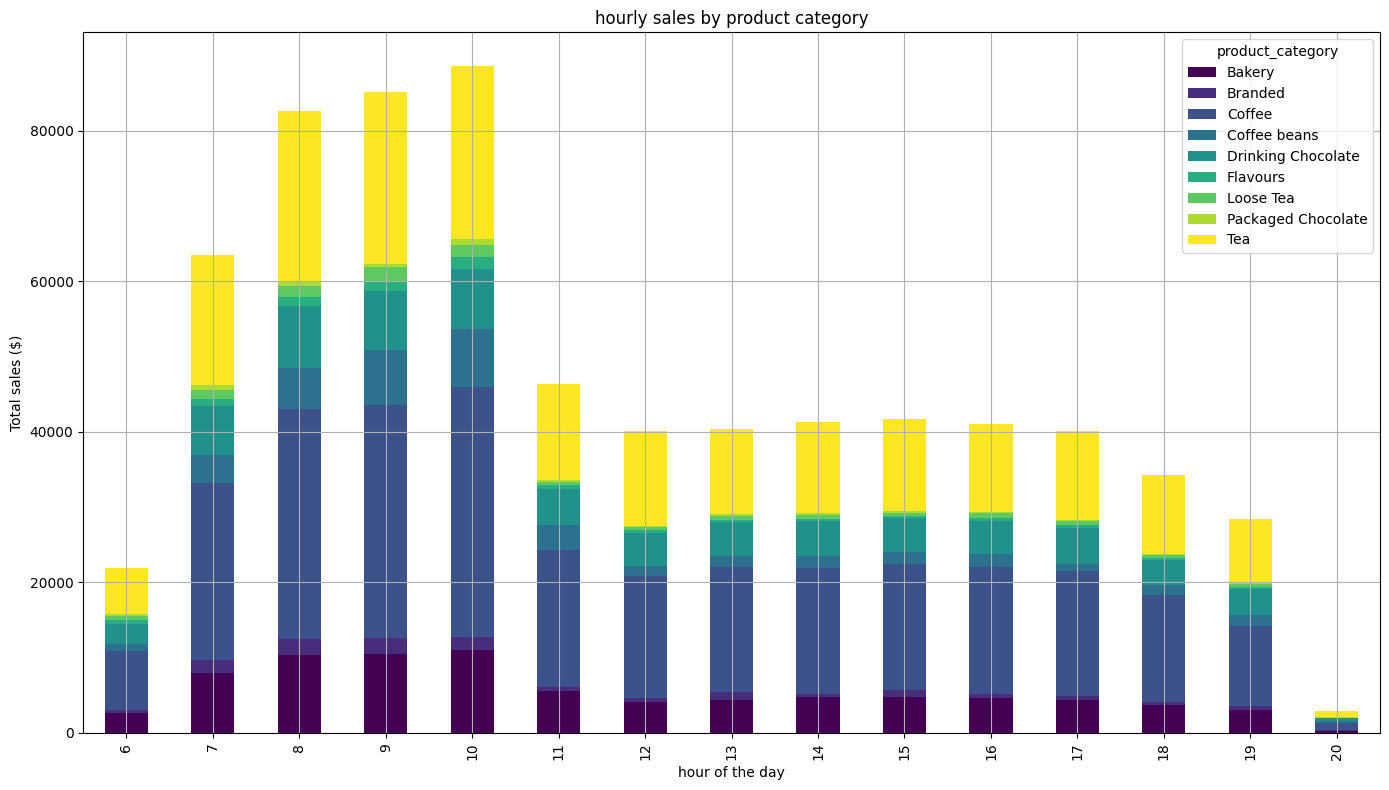

In [85]:
df['hour'] = df['datetime'].dt.hour
hourly_sales_by_product = df.groupby(['hour', 'product_category'])['sales'].sum().unstack()

hourly_sales_by_product.plot(kind='bar',stacked=True, figsize=(14, 8), colormap='viridis')

plt.title('hourly sales by product category')
plt.xlabel('hour of the day')
plt.ylabel('Total sales ($)')
plt.legend(title='product_category', loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [86]:
df_category['avg_sales'] = df_category['sales']/df_category['transaction_id']
df_category

,sales,transaction_id,avg_sales
product_category,,,
Coffee,269952.45,58416,4.621207
Tea,196405.95,45449,4.321458
Bakery,82315.64,22796,3.610969
Drinking Chocolate,72416.00,11468,6.314615
Coffee beans,40085.25,1753,22.866657
Branded,13607.00,747,18.215529
Loose Tea,11213.60,1210,9.267438
Flavours,8408.80,6790,1.238409
Packaged Chocolate,4407.64,487,9.050595


In [1]:
sales_by_product = df.groupby('product_type').agg({
    'sales': 'sum',
    'unit_price': 'mean'
}).sort_values('sales', ascending = False)
sales_by_product

NameError: name 'df' is not defined

In [93]:
product_sales_df = df.groupby(['product_category', 'product_type'])['sales'].sum().reset_index()
product_sales_df

,product_category,product_type,sales
0,Bakery,Biscotti,19793.53
1,Bakery,Pastry,25655.99
2,Bakery,Scone,36866.12
3,Branded,Clothing,6163.00
4,Branded,Housewares,7444.00
5,Coffee,Barista Espresso,91406.20
6,Coffee,Drip coffee,31984.00
7,Coffee,Gourmet brewed coffee,70034.60
8,Coffee,Organic brewed coffee,37746.50
9,Coffee,Premium brewed coffee,38781.15


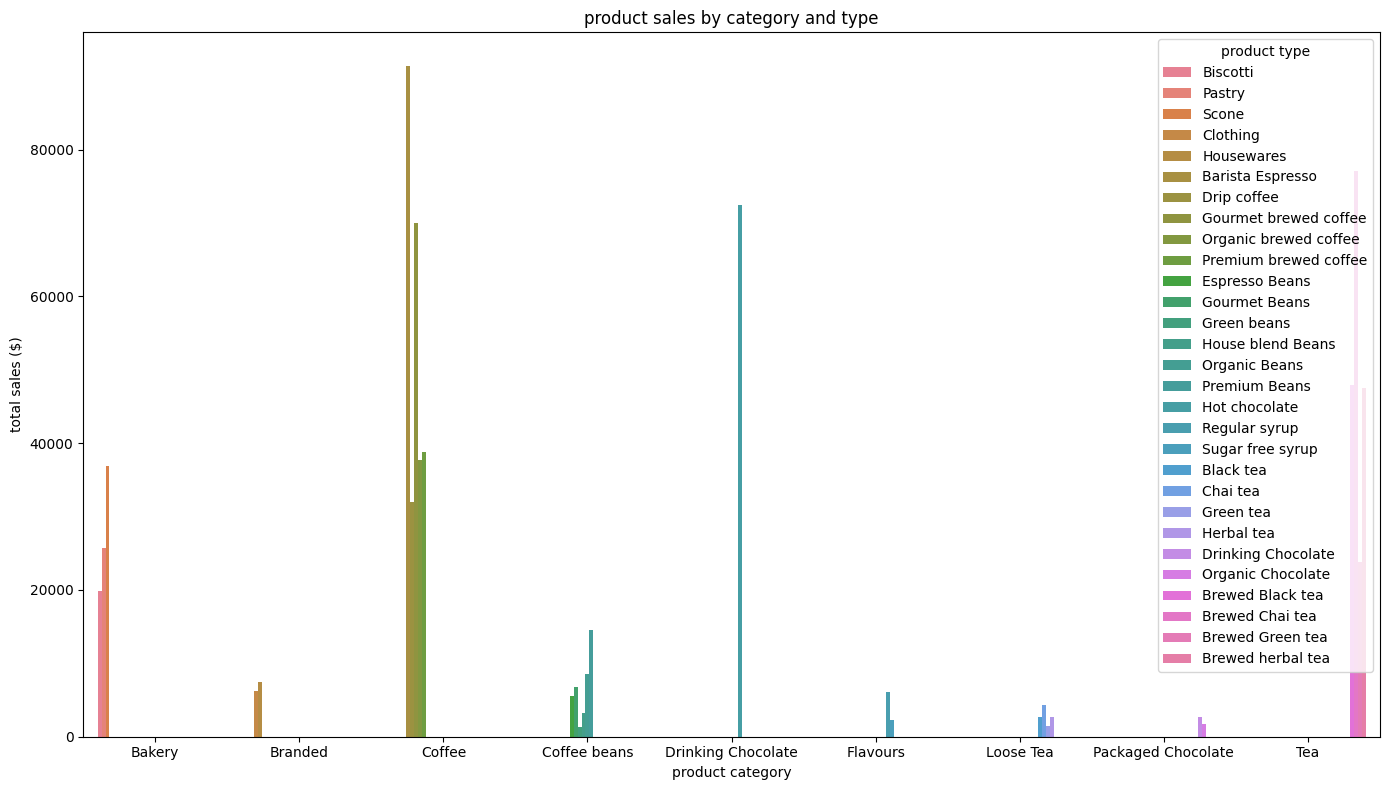

In [96]:
plt.figure(figsize = (14, 8))
sns.barplot(data =product_sales_df, x='product_category', y='sales', hue='product_type')

plt.title('product sales by category and type')
plt.xlabel('product category')
plt.ylabel('total sales ($)')
plt.legend(title='product type', loc='upper right')

plt.tight_layout()
plt.show()

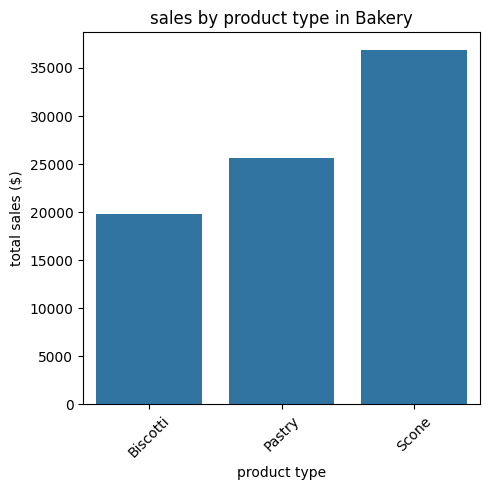

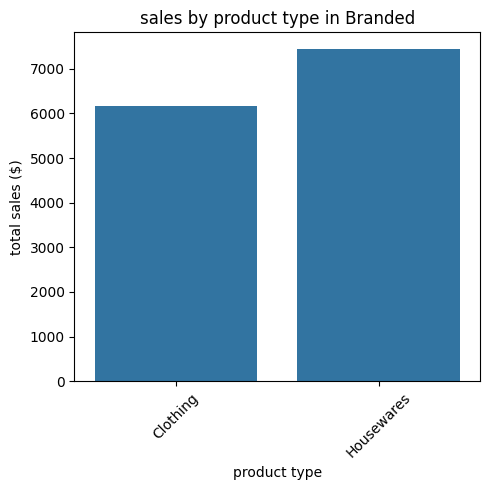

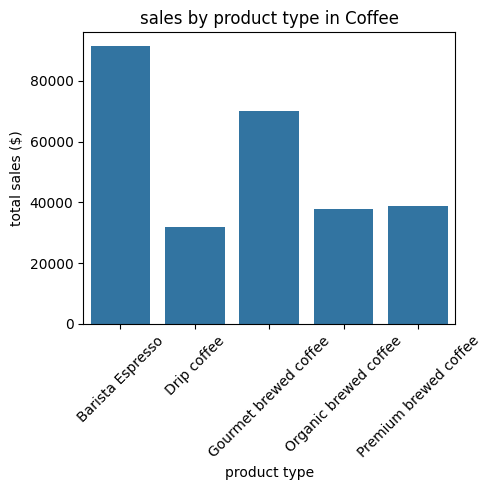

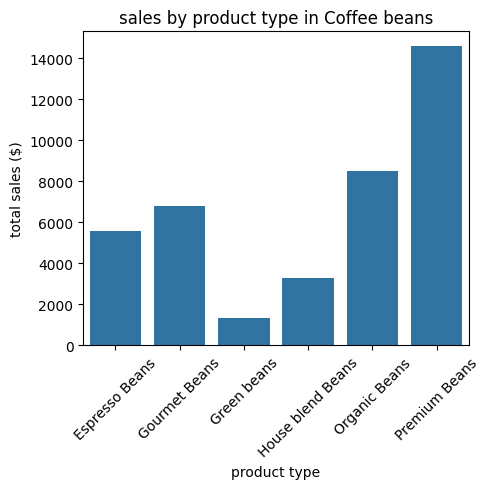

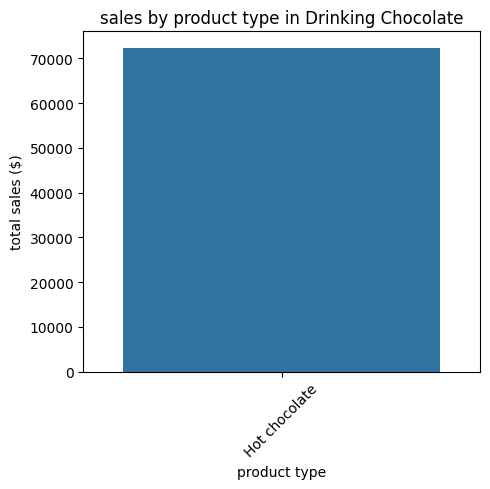

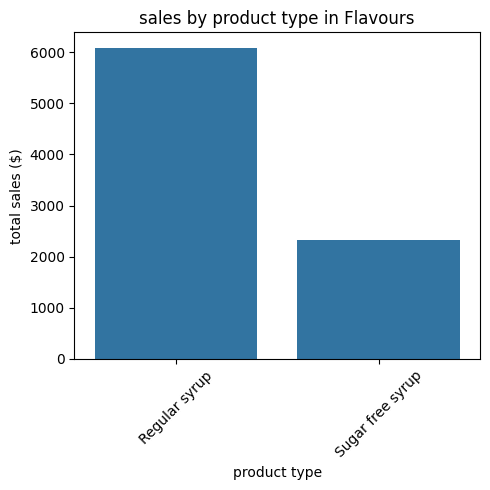

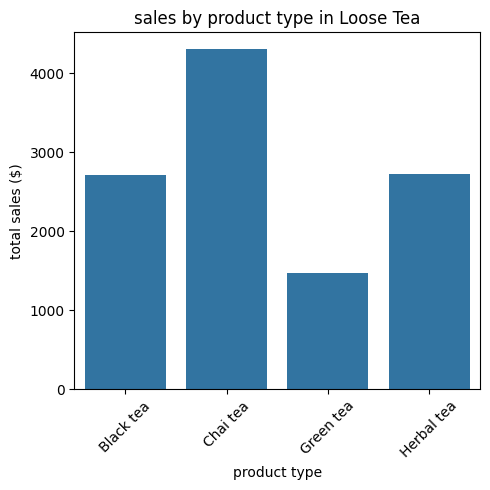

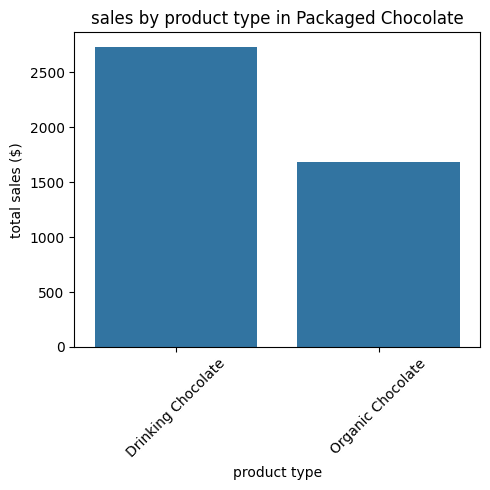

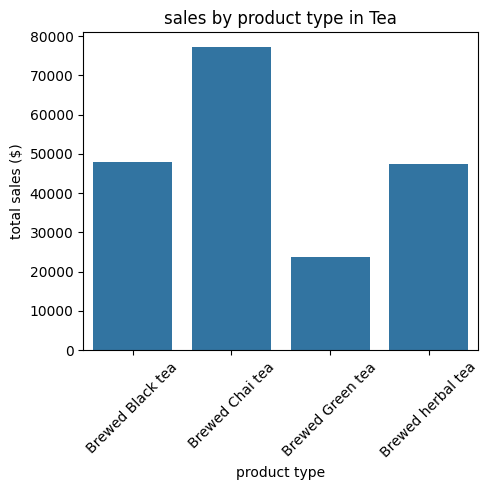

In [99]:
categories = product_sales_df['product_category'].unique()

for category in categories:
    plt.figure(figsize=(5, 5))
    category_data = product_sales_df[product_sales_df['product_category'] == category]
    sns.barplot(data=category_data, x='product_type', y='sales')

    #add labels and title
    plt.title(f'sales by product type in {category}')
    plt.xlabel('product type')
    plt.ylabel('total sales ($)')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [100]:
hourly_sales_by_location = df.groupby(['store_location', 'hour'])['sales'].sum().reset_index()
hourly_sales_by_location

,store_location,hour,sales
0,Astoria,7,19028.80
1,Astoria,8,22805.90
2,Astoria,9,23183.57
3,Astoria,10,24426.12
4,Astoria,11,15498.13
5,Astoria,12,15681.20
6,Astoria,13,15947.87
7,Astoria,14,15175.27
8,Astoria,15,15651.95
9,Astoria,16,16110.85


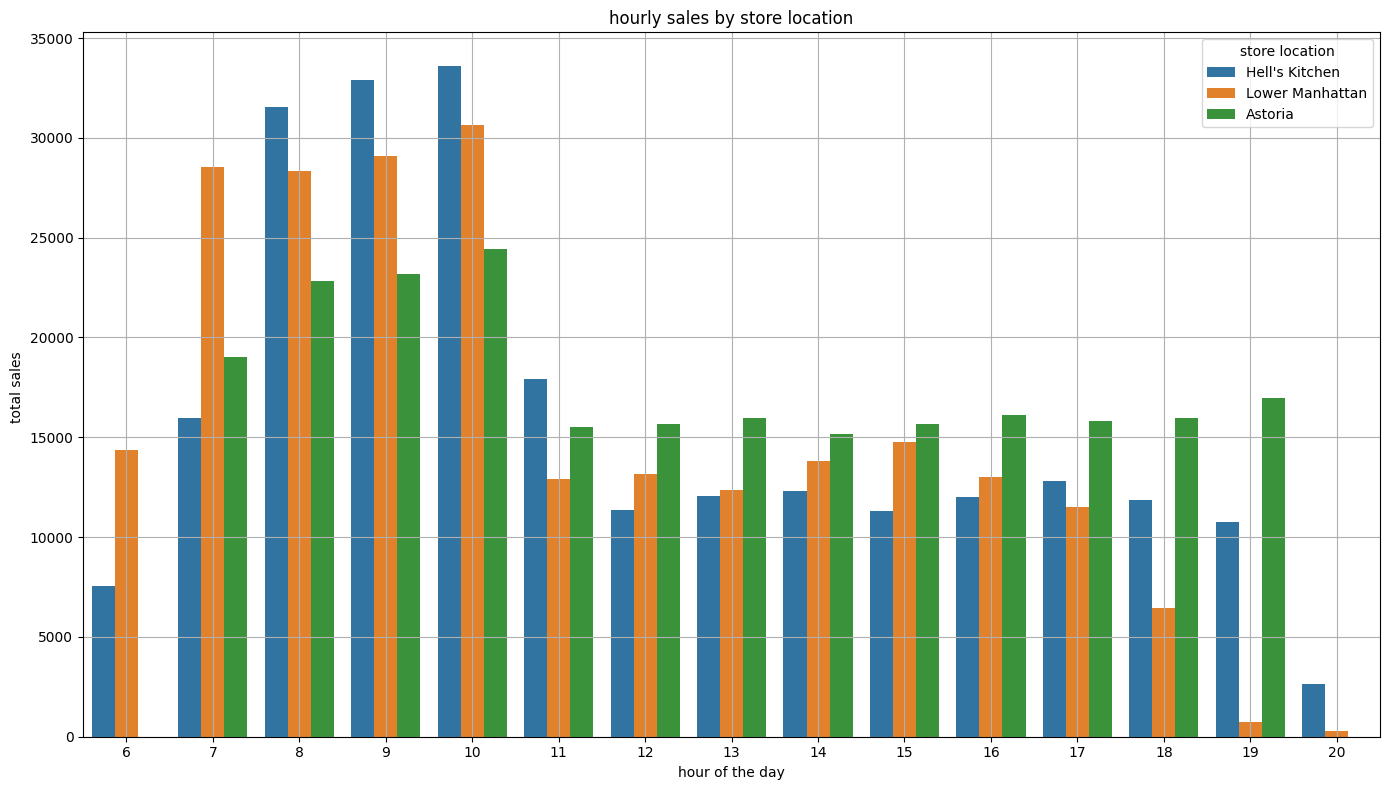

In [102]:
plt.figure(figsize= (14, 8))
sns.barplot(data=hourly_sales_by_location, x='hour',y='sales',hue='store_location')

plt.title('hourly sales by store location')
plt.xlabel('hour of the day')
plt.ylabel('total sales ')
plt.legend(title='store location', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()